In [1]:
!pip install tensorflow matplotlib scikit-learn
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
x_train = x_train[..., None]
x_test = x_test[..., None]
model = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(x_train, y_train, epochs=3, batch_size=128, validation_data=(x_test, y_test))
# Evaluasi
y_pred = np.argmax(model.predict(x_test), axis=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 107ms/step - accuracy: 0.9407 - loss: 0.2077 - val_accuracy: 0.9808 - val_loss: 0.0633
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.9830 - loss: 0.0556 - val_accuracy: 0.9876 - val_loss: 0.0392
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9888 - loss: 0.0376 - val_accuracy: 0.9893 - val_loss: 0.0296
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
def preprocessing(gray_img):
    # add channel cause cnn model work on 3d image
    gray_img = np.expand_dims(gray_img, axis=-1)
    # Note we can use normaliztion from sklearn but i want to use it
    gray_img = gray_img.astype('float32')
    # normalize image
    gray_img =gray_img/255 # float data type must value betwwn 0.0 and 1.1
    #plt.imshow(resize_img)
    #plt.show()
    return gray_img
def Vsualize_History(history):
    plt.figure(figsize=(7, 15))
    # First graph
    history[['loss','val_loss']].plot()
    plt.title('train Vs Validition Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Second graph
    history[['accuracy','val_accuracy']].plot()
    plt.title('train Vs Validition score')
    plt.xlabel('Epochs')
    plt.ylabel('score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
plt.show()

In [8]:
def Predict(x_test,y_test):
    ypred=model.predict(x_test)
    ypred_class = np.argmax(ypred, axis=1) # to choose index(number) of max probabilty
    print("Accuracy = ",accuracy_score(y_test, ypred_class)*100)
    report = classification_report(y_test, ypred_class)
    print("Classification Report: \n")
    print(report)
    plt.figure(figsize=(7,6))
    cm=confusion_matrix(y_test,ypred_class)
    sns.heatmap(cm.round(2),fmt="d", annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Acutal')
    plt.show()

In [9]:
 (x_train,y_train),(x_test,y_test) = mnist.load_data()

In [10]:
#shape od data
print('shape train dataset: ' ,x_train.shape)
print('shape label of train dataset: ' ,y_train.shape)
print('shape test dataset: ' ,x_test.shape)
print('shape label of test dataset: ' ,y_test.shape)

shape train dataset:  (60000, 28, 28)
shape label of train dataset:  (60000,)
shape test dataset:  (10000, 28, 28)
shape label of test dataset:  (10000,)


In [11]:
#labels
print(f'Classes = {np.unique(y_train)}')
print(f'Number of Classes = {len(np.unique(y_train))}')

Classes = [0 1 2 3 4 5 6 7 8 9]
Number of Classes = 10


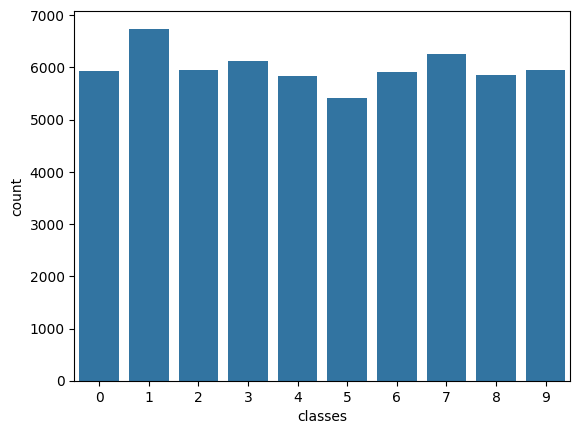

In [12]:
sns.countplot(x=y_train)
plt.xlabel('classes')
plt.show()

In [13]:
x_train = preprocessing(x_train)
x_test = preprocessing(x_test)

#shape od data
print('shape train dataset: ' ,x_train.shape)
print('shape label of train dataset: ' ,y_train.shape)
print('shape test dataset: ' ,x_test.shape)
print('shape label of test dataset: ' ,y_test.shape)

shape train dataset:  (60000, 28, 28, 1)
shape label of train dataset:  (60000,)
shape test dataset:  (10000, 28, 28, 1)
shape label of test dataset:  (10000,)


In [14]:
# After normalization
print(f'min = {x_train.min()} , max = {x_train.max()} ')
print(f'min = {x_test.min()} , max = {x_test.max()} ')

min = 0.0 , max = 1.0 
min = 0.0 , max = 1.0 


(28, 28, 1)


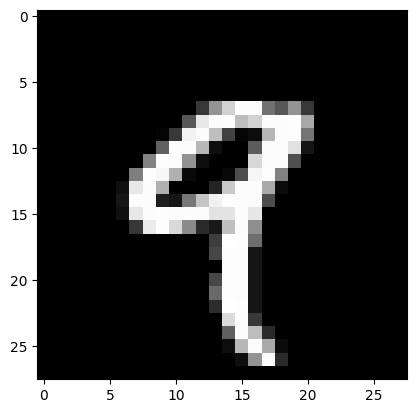

(28, 28, 1)
(784,)


In [16]:
# show image
img = x_train[4]
print(img.shape)
plt.imshow(img,cmap='gray')
plt.show()

print(img.shape)
print(img.flatten().shape) # result of 28*28*1


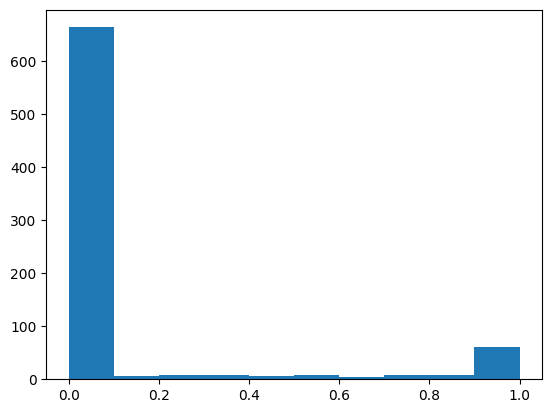

In [17]:
# Using flatten to convert dim to 1dim to show histogram of it
plt.hist(img.flatten())
plt.show()

In [19]:
def Model():
    model =keras.Sequential([
    layers.Conv2D(32,kernel_size =(3,3), strides=(1,1), activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Conv2D(64,kernel_size = (3,3), strides=(1,1), activation='relu'),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Conv2D(64,kernel_size = (3,3), strides=(1,1), activation='relu'),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10, activation='softmax')
    ])
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    #Using crossentropy loss function cause we have more than 2 label classes.
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics =['accuracy'])
    return model

In [21]:
model = Model()
model.summary()
history = model.fit(x_train, y_train, epochs=10,batch_size=64, validation_split=0.2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,354 (255.29 KB)

 Trainable params: 65,354 (255.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.9336 - loss: 0.2092 - val_accuracy: 0.9716 - val_loss: 0.0971
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.9699 - loss: 0.1041 - val_accuracy: 0.9714 - val_loss: 0.0973
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9739 - loss: 0.0903 - val_accuracy: 0.9766 - val_loss: 0.0810
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9762 - loss: 0.0865 - val_accuracy: 0.9746 - val_loss: 0.0920
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.9784 - loss: 0.0775 - val_accuracy: 0.9723 - val_loss: 0.0966
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.9803 - loss: 0.0737 - val_accuracy: 0.9789 - val_loss: 0.0872
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9812 - loss: 0.0702 - val_accuracy: 0.9797 - val_loss: 0.0838
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9813 - loss: 0.0715 - 

<Figure size 700x1500 with 0 Axes>

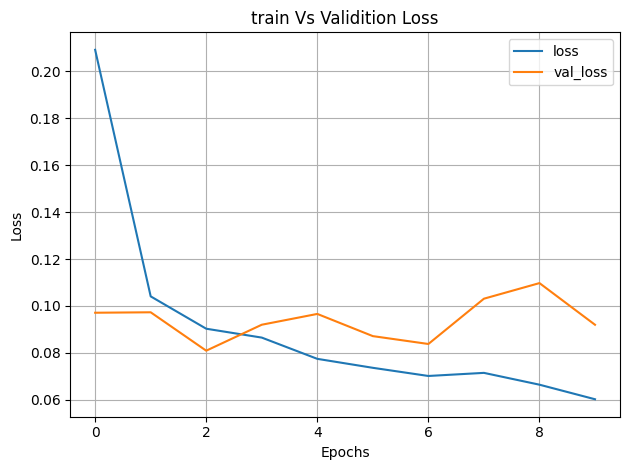

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Accuracy =  97.61999999999999
Classification Report: 

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.97      0.97      1032
           3       1.00      0.97      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.94      0.99      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



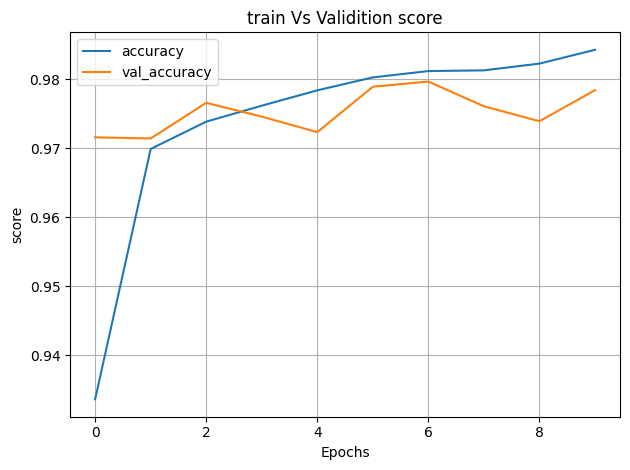

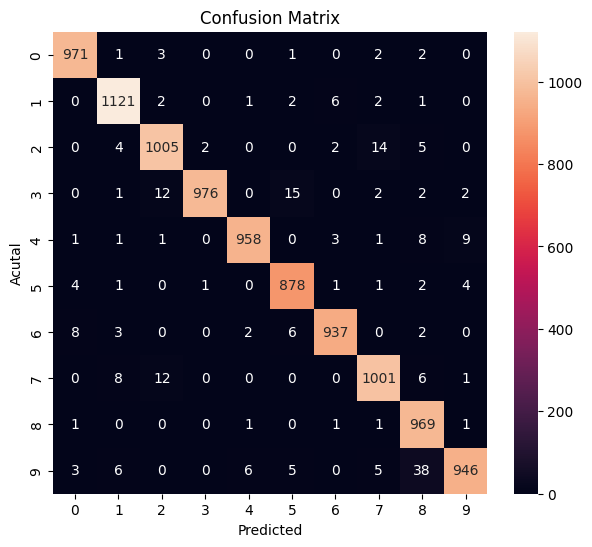

In [22]:
result = pd.DataFrame(history.history)
result.shape
result.sample(10)
Vsualize_History(result)
Predict(x_test,y_test)

In [23]:
# Arsitektur Diagram
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='cnn_model_structure.png', show_shapes=True, show_layer_names=True, show_layer_activations=True)
model.save("cnn_mnist_cnn_model.h5")
print(" Model has been saved successfully as 'mnist_cnn_model.h5'")

 Model has been saved successfully as 'mnist_cnn_model.h5'


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2187s 13us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.4346 - loss: 1.5502 - val_accuracy: 0.5392 - val_loss: 1.2682
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.5761 - loss: 1.1935 - val_accuracy: 0.6035 - val_loss: 1.1172
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6328 - loss: 1.0428 - val_accuracy: 0.6390 - val_loss: 1.0267
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6647 - loss: 0.9534 - val_accuracy: 0.6330 - val_loss: 1.0288
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6914 - loss: 0.8790 - val_accuracy: 0.6765 - val_loss: 0.9136
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7120 - loss: 0.8211 - val_accuracy: 0.6793 - val_loss: 0.8998
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.7307 - loss: 0.7743 - val_accuracy: 0.7021 - val_loss: 0.8667
Epoch 8/10
1563/156

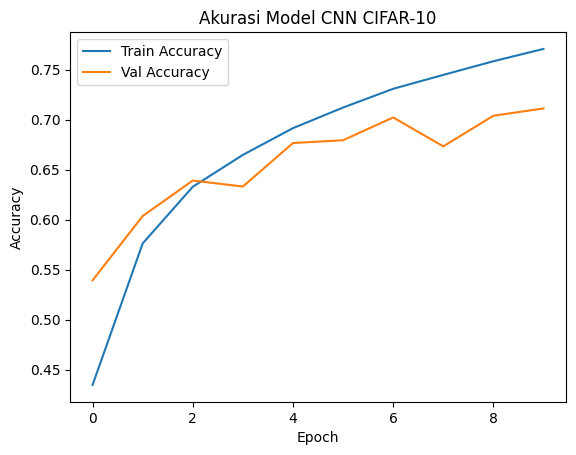

In [ ]:
# 1. Load dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
# 2. Definisi model CNN
model = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')
])
# 3. Kompilasi model
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# 4. Training
history = model.fit(x_train, y_train, epochs=10,
validation_data=(x_test, y_test))

# 5. Evaluasi
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nAkurasi test: {test_acc:.4f}')
# 6. Visualisasi Akurasi & Loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model CNN CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# ResNet untuk CIFAR-10 (Training, Evaluasi, dan Visualisasi)
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# 1. Load dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
# Label names CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']
# 2. Visualisasi sample gambar
plt.figure(figsize=(10,4))
for i in range(10):
plt.subplot(2,5,i+1)
plt.imshow(x_train[i])
plt.title(class_names[int(y_train[i])])
plt.axis('off')
plt.suptitle('Contoh Gambar CIFAR-10')
plt.show()

In [ ]:
#3. Definisi residual block
def residual_block(x, filters, downsample=False):
y = layers.Conv2D(filters, (3,3), padding='same', strides=(2 if downsample else 1))(x)
y = layers.BatchNormalization()(y)
y = layers.ReLU()(y)
y = layers.Conv2D(filters, (3,3), padding='same')(y)
y = layers.BatchNormalization()(y)
if downsample:
x = layers.Conv2D(filters, (1,1), strides=2, padding='same')(x)
out = layers.Add()([x, y])
out = layers.ReLU()(out)
return out


In [ ]:
# 4. Bangun arsitektur ResNet sederhana
inputs = layers.Input(shape=(32,32,3))
x = layers.Conv2D(64, (3,3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 64)
x = residual_block(x, 128, downsample=True)
x = residual_block(x, 256, downsample=True)
x = residual_block(x, 512, downsample=True)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = models.Model(inputs, outputs)
# 5. Kompilasi model
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
model.summary()
# 6. Training model
history = model.fit(x_train, y_train, epochs=10, batch_size=64,
validation_data=(x_test, y_test))
# 7. Evaluasi performa
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nAkurasi Test: {test_acc:.4f}')


In [ ]:
# 8. Visualisasi akurasi dan loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# 9. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix CIFAR-10 ResNet')
plt.show()

# 10. Visualisasi Prediksi Contoh
plt.figure(figsize=(10,6))
for i in range(10):
idx = np.random.randint(0, len(x_test))
img = x_test[idx]
true_label = class_names[int(y_test[idx])]
pred_label = class_names[y_pred[idx]]
plt.subplot(2,5,i+1)
plt.imshow(img)
color = 'green' if true_label == pred_label else 'red'
plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
plt.axis('off')
plt subtitle('Prediksi Model ResNet pada CIFAR-10')
